# Assignment 3: Central Park Attractions Network

I want to compare lengths of Euclidean and Network routes through Central Park Attractions.

First I find the shortest possible route that visits every tourist attraction in Central Park exactly once, starting from a fixed location (**Central Park Entry**) and ending wherever is most efficient.

For this first pass, we treat distance as straight-line (**Euclidean**) distance between points, ignoring the actual park paths and roads. The resulting route will be drawn as a single polyline made up of straight segments connecting each attraction to the next, in visiting order.

## Import libraries

In [90]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
from shapely.geometry import LineString
from shapely.ops import substring

In [91]:
from cdptools import utils

utils.set_axis_off()

## Load the attraction points

The GeoJSON already lists **Central Park Entry** as the first feature, which is exactly the fixed starting point we want (index `0`)

In [92]:
gdf = gpd.read_file("Central_Park_Tourist_Attractions.geojson")

start_label = "Central Park Entry"
assert gdf.loc[0, "label"] == start_label

gdf

,label,geometry
0,Central Park Entry,POINT (-73.97624 40.7657)
1,"Central Park Zoo - 830 5th Avenue, New York, N...",POINT (-73.97147 40.76772)
2,Bethesda Terrace & Fountain,POINT (-73.9709 40.77413)
3,Bow Bridge,POINT (-73.97177 40.77577)
4,Belvedere Castle,POINT (-73.9689 40.7793)
5,The Great Lawn,POINT (-73.96787 40.78043)
6,Strawberry Fields,POINT (-73.97523 40.77589)
7,The Mall and Literary Walk,POINT (-73.97188 40.77161)
8,Sheep Meadow,POINT (-73.97596 40.77094)
9,Conservatory Water,POINT (-73.96757 40.77439)


## Plot the raw points

Text(0.5, 1.0, 'Central Park Attractions (input order, before routing)')

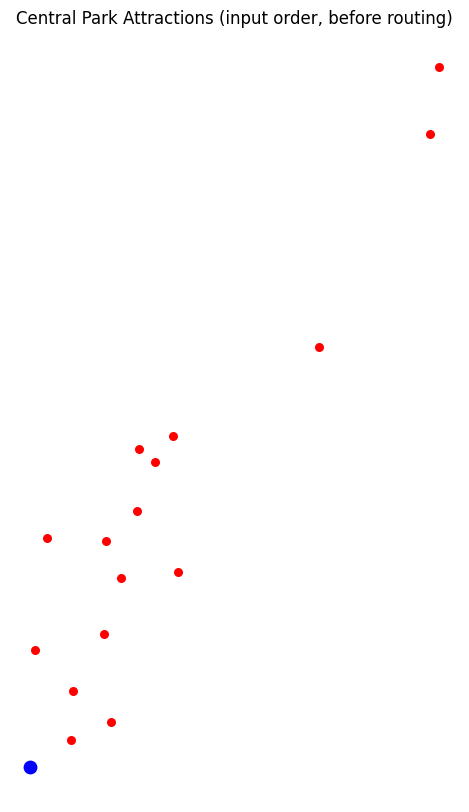

In [93]:
ax = gdf.plot(color="red", markersize=30, figsize=(8, 10))
gdf[gdf["label"] == start_label].plot(ax=ax, color="blue", markersize=80)
ax.set_title("Central Park Attractions (input order, before routing)")

## Build a Euclidean distance matrix

To measure straight-line distance accurately (in meters, rather than degrees of latitude/longitude), we project the points into a metric coordinate system - UTM Zone 18N (`EPSG:32618`), which covers New York City - before computing pairwise distances. The resulting route will still be drawn using the original (unprojected) point geometry.

In [94]:
gdf_proj = gdf.to_crs(epsg=32618)
coords = np.column_stack([gdf_proj.geometry.x, gdf_proj.geometry.y])

n = len(coords)
dist = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dist[i, j] = np.linalg.norm(coords[i] - coords[j])

dist.shape

(17, 17)

## Find the shortest full route (fixed start)

We want a route that:
- starts at node `0` (Central Park Entry),
- visits every other node exactly once

We'll build it based on nearest neighbors.From the current point, always jump to the closest point that hasn't been visited yet, and repeat until every point has been visited.

In [95]:
def nearest_neighbor_route(dist, start=0):
    """Greedy nearest-neighbor route construction with a fixed start.
    Returns (path, total_distance)."""

    n = dist.shape[0]
    path = [start]
    remaining = set(range(n)) - {start}
    total_distance = 0.0
    current = start

    while remaining:
        next_point = min(remaining, key=lambda j: dist[current, j])
        total_distance += dist[current, next_point]
        path.append(next_point)
        remaining.remove(next_point)
        current = next_point

    return path, total_distance

In [96]:
nn_path, nn_distance = nearest_neighbor_route(dist, start=0)

print("Nearest-neighbor visiting order (indices):", nn_path)
print(
    f"Nearest-neighbor route length: {nn_distance:,.0f} m ({nn_distance / 1609.34:.2f} mi)"
)

Nearest-neighbor visiting order (indices): [0, 15, 1, 16, 8, 7, 2, 3, 13, 4, 14, 5, 9, 6, 12, 10, 11]
Nearest-neighbor route length: 7,082 m (4.40 mi)


### Cleaning up with 2-opt

Because nearest-neighbor only ever looks one step ahead, it can strand an outlying point - it gets skipped early because something else was slightly closer at that moment, and then has to be visited late with a long detour to reach it.

We can clean this up with **2-opt**: repeatedly look for two edges in the route that cross or backtrack, and check whether reversing the stretch of the path between them shortens the total route. If it does, keep the reversal; otherwise leave it. We repeat this until no more improving swap can be found. The starting point (index `0`) is never moved, so the route still begins at Central Park Entry.

In [97]:
def two_opt(path, dist, max_passes=100):
    """Improve an open route by repeatedly reversing segments whenever doing
    so shortens the total distance. Keeps path[0] (the fixed start) in place."""

    path = list(path)
    n = len(path)
    improved = True
    passes = 0

    while improved and passes < max_passes:
        improved = False
        passes += 1
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                a, b = path[i - 1], path[i]
                c = path[j]
                d = path[j + 1] if j + 1 < n else None

                old_cost = dist[a, b] + (dist[c, d] if d is not None else 0)
                new_cost = dist[a, c] + (dist[b, d] if d is not None else 0)

                if new_cost < old_cost - 1e-9:
                    path[i : j + 1] = path[i : j + 1][::-1]
                    improved = True

    total_distance = sum(dist[path[k], path[k + 1]] for k in range(n - 1))
    return path, total_distance

In [98]:
path, total_distance = two_opt(nn_path, dist)

print("Final visiting order (indices):", path)
print(
    f"Final route length: {total_distance:,.0f} m ({total_distance / 1609.34:.2f} mi)"
)
print(
    f"Improvement over nearest-neighbor: {(nn_distance - total_distance) / 1609.34:.2f} mi"
)

Final visiting order (indices): [0, 15, 1, 16, 8, 7, 6, 3, 2, 9, 13, 4, 14, 5, 12, 10, 11]
Final route length: 5,934 m (3.69 mi)
Improvement over nearest-neighbor: 0.71 mi


## Build the route as a polyline

Now that we have the nearest-neighbor visiting order, we reorder the geodataframe accordingly and connect the points, in order, with straight-line (`LineString`) segments.

In [99]:
ordered_gdf = gdf.loc[path].reset_index(drop=True)

route_line = LineString(ordered_gdf.geometry.tolist())
route_gdf = gpd.GeoDataFrame(geometry=[route_line], crs=gdf.crs)

ordered_gdf[["label"]]

,label
0,Central Park Entry
1,Gapstow Bridge
2,"Central Park Zoo - 830 5th Avenue, New York, N..."
3,Dairy Visitor Center
4,Sheep Meadow
5,The Mall and Literary Walk
6,Strawberry Fields
7,Bow Bridge
8,Bethesda Terrace & Fountain
9,Conservatory Water


## Plot the final route

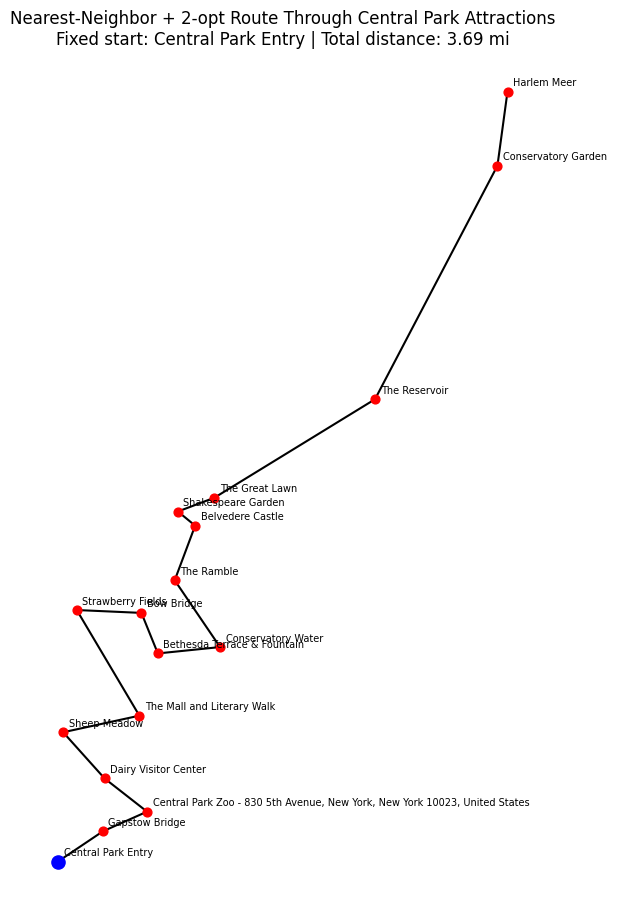

In [100]:
fig, ax = plt.subplots(figsize=(9, 11))

route_gdf.plot(ax=ax, color="black", linewidth=1.5, zorder=1)
gdf.plot(ax=ax, color="red", markersize=40, zorder=2)
gdf[gdf["label"] == start_label].plot(ax=ax, color="blue", markersize=90, zorder=3)

for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf["label"]):
    ax.annotate(label, xy=(x, y), xytext=(4, 4), textcoords="offset points", fontsize=7)

ax.set_title(
    f"Nearest-Neighbor + 2-opt Route Through Central Park Attractions\n"
    f"Fixed start: {start_label} | Total distance: {total_distance / 1609.34:.2f} mi"
)

# save the canvas so the route can be printed
fig.savefig("central_park_route.pdf", bbox_inches="tight", pad_inches=0.1)

# Part 2: Central Park Street & Path Network

Now let's get the actual walking paths inside Central Park, the same way the networks tutorial gets the street network around a subway station: with **OSMnx**, which queries OpenStreetMap's **Overpass API** and returns a `networkx.MultiDiGraph`.

The tutorial queries a fixed-radius circle around a single point (`ox.graph_from_point(point, dist=1000, network_type="walk")`). We instead want the network for the whole park, so we'll use `ox.graph_from_bbox()` with a bounding box built from `Central_Park_Outline.geojson`, and `network_type="walk"` to get pedestrian paths rather than roads for cars.

## Build a bounding box from the park outline

We load the outline and take its `total_bounds` - `(minx, miny, maxx, maxy)`, i.e. `(west, south, east, north)`. This project uses `osmnx==2.1.0` (see `requirements.txt`), whose `graph_from_bbox()` expects the bbox in exactly that `(west, south, east, north)` order - the same order GeoPandas already gives us, so no reordering is needed here (older OSMnx versions, like the one referenced in the tutorial's text, expected `(north, south, east, west)` instead - worth double-checking if you're on a different version).

In [101]:
outline_gdf = gpd.read_file("Central_Park_Outline.geojson")

west, south, east, north = outline_gdf.total_bounds
bbox = (west, south, east, north)
bbox

(np.float64(-73.981752),
 np.float64(40.764545),
 np.float64(-73.949381),
 np.float64(40.800542))

## Query the walking-path network

Just like `ox.graph_from_point()` in the tutorial, `ox.graph_from_bbox()` sends a request to the Overpass API and returns everything within the bounding box, filtered by `network_type`. We use `"walk"` since we want pedestrian paths through the park, not roads for cars. Note that the park's outer drive (a road, technically) will still be picked up by `"walk"`, since it has sidewalks/paths alongside it in OSM data - that's fine, it's a real path people use.

In [102]:
park_network = ox.graph_from_bbox(bbox, network_type="walk")
park_network

### Convert to geodataframes

As in the tutorial, we split the graph into node and edge geodataframes with `ox.graph_to_gdfs()`, and plot the edges to confirm we captured the park's path network.

In [103]:
park_nodes, park_edges = ox.graph_to_gdfs(park_network)
park_edges.head()

osmid    highway  oneway reversed      length  \
u        v          key                                                      
30807314 2057103273 0     46613689  bridleway   False    False  159.255042   
         6579409036 0     46613689  bridleway   False     True   58.144181   
         4303265016 0    147089927    footway   False    False   10.509449   
         1203806304 0    147089927    footway   False     True   17.645411   
30978747 42442164   0    429504381       path   False    False   18.986534   

                                                                  geometry  \
u        v          key                                                      
30807314 2057103273 0    LINESTRING (-73.96358 40.79072, -73.9636 40.79...   
         6579409036 0    LINESTRING (-73.96358 40.79072, -73.96354 40.7...   
         4303265016 0    LINESTRING (-73.96358 40.79072, -73.96353 40.7...   
         1203806304 0    LINESTRING (-73.96358 40.79072, -73.96368 40.7...   
30978747 42442164   0    LINESTRING (-73.97342 40.77427, -73.97365 40.7...   

                                          name lanes maxspeed width bridge  \
u        v          key                                                      
30807314 2057103273 0                      NaN   NaN      NaN   NaN    NaN   
         6579409036 0                      NaN   NaN      NaN   NaN    NaN   
         4303265016 0                      NaN   NaN      NaN   NaN    NaN   
         1203806304 0                      NaN   NaN      NaN   NaN    NaN   
30978747 42442164   0    Central Park Driveway   NaN      NaN   NaN    NaN   

                        service access tunnel junction area  
u        v          key                                      
30807314 2057103273 0       NaN    NaN    NaN      NaN  NaN  
         6579409036 0       NaN    NaN    NaN      NaN  NaN  
         4303265016 0       NaN    NaN    NaN      NaN  NaN  
         1203806304 0       NaN    NaN    NaN      NaN  NaN  
30978747 42442164   0       NaN    NaN    NaN      NaN  NaN

Text(0.5, 1.0, 'Central Park Walking-Path Network (OSMnx / OpenStreetMap)')

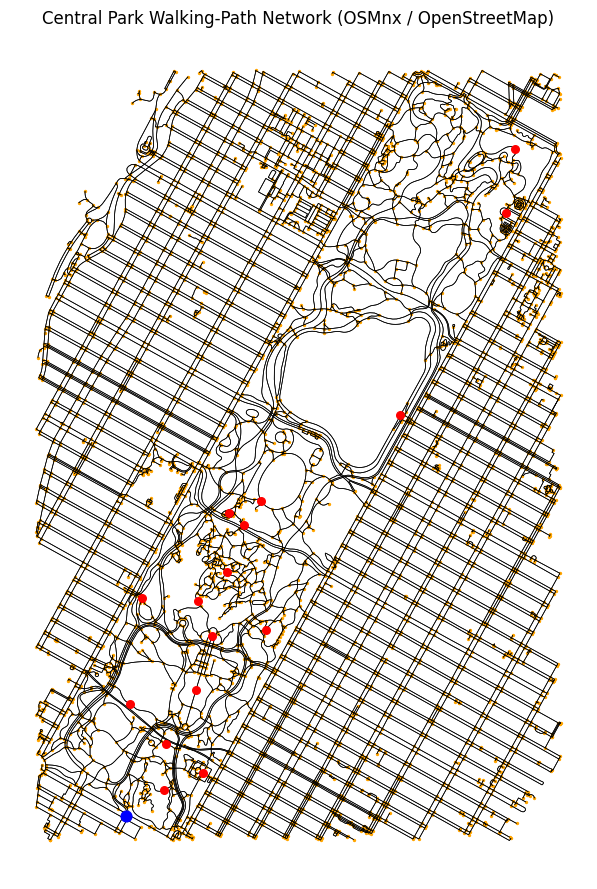

In [104]:
ax = park_edges.plot(color="black", linewidth=0.5, figsize=(9, 11))
park_nodes.plot(ax=ax, color="orange", markersize=2)
gdf.plot(ax=ax, color="red", markersize=30, zorder=3)
gdf[gdf["label"] == start_label].plot(ax=ax, color="blue", markersize=60, zorder=4)
ax.set_title("Central Park Walking-Path Network (OSMnx / OpenStreetMap)")

## Snap attractions to the network

 Instead of snapping to the nearest *node*, we snap to the nearest *edge* with `ox.distance.nearest_edges()`, find exactly where along that edge's geometry the point projects to, and **split the edge there**, inserting a brand-new routing node at that precise location. This keeps every attraction snapped to within about a meter of its real position, no matter how sparse the surrounding path network is.

In [105]:
def snap_point_to_graph(G, point, node_id):
    """Insert `point` into graph `G` as a new node `node_id`, by splitting
    whichever edge it's closest to at the exact point it projects onto.
    Splits both directions of the edge, if the reverse edge exists."""

    u, v, k = ox.distance.nearest_edges(G, point.x, point.y)
    edge_geom = G.edges[u, v, k].get(
        "geometry",
        LineString(
            [(G.nodes[u]["x"], G.nodes[u]["y"]), (G.nodes[v]["x"], G.nodes[v]["y"])]
        ),
    )
    frac = edge_geom.project(point, normalized=True)
    snapped_pt = edge_geom.interpolate(frac, normalized=True)
    G.add_node(node_id, x=snapped_pt.x, y=snapped_pt.y)

    def split_edge(a, b, key):
        if not G.has_edge(a, b, key):
            return
        data = dict(G.edges[a, b, key])
        geom = data.get(
            "geometry",
            LineString(
                [(G.nodes[a]["x"], G.nodes[a]["y"]), (G.nodes[b]["x"], G.nodes[b]["y"])]
            ),
        )
        f = geom.project(point, normalized=True)
        base_len = data.get("length", geom.length)
        G.remove_edge(a, b, key)

        first_half = dict(
            data, geometry=substring(geom, 0, f, normalized=True), length=base_len * f
        )
        second_half = dict(
            data,
            geometry=substring(geom, f, 1, normalized=True),
            length=base_len * (1 - f),
        )
        G.add_edge(a, node_id, key, **first_half)
        G.add_edge(node_id, b, key, **second_half)

    split_edge(u, v, k)
    split_edge(v, u, k)


gdf["node"] = [f"attraction_{i}" for i in gdf.index]
for i, row in gdf.iterrows():
    snap_point_to_graph(park_network, row.geometry, row["node"])

gdf[["label", "node"]]

,label,node
0,Central Park Entry,attraction_0
1,"Central Park Zoo - 830 5th Avenue, New York, N...",attraction_1
2,Bethesda Terrace & Fountain,attraction_2
3,Bow Bridge,attraction_3
4,Belvedere Castle,attraction_4
5,The Great Lawn,attraction_5
6,Strawberry Fields,attraction_6
7,The Mall and Literary Walk,attraction_7
8,Sheep Meadow,attraction_8
9,Conservatory Water,attraction_9


## Build a network-distance matrix

Just like the Euclidean `dist` matrix in Part 1, we need a 17x17 matrix of distances between every pair of attractions - but this time, distance means "shortest walk along the park's paths" rather than "straight line." For each pair of snapped nodes, we use `networkx.shortest_path_length()` with `weight="length"` (the same weighting the tutorial uses for `ox.shortest_path()`) to get the walking distance in meters.

Because `park_network` is a directed graph, we check both directions and warn if a pair turns out to be unreachable (which would mean the bbox query left the network disconnected somewhere).

In [106]:
nodes = gdf["node"].tolist()
n = len(nodes)
net_dist = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            continue
        try:
            net_dist[i, j] = nx.shortest_path_length(
                park_network, nodes[i], nodes[j], weight="length"
            )
        except nx.NetworkXNoPath:
            print(
                f"No path between '{gdf.loc[i, 'label']}' and '{gdf.loc[j, 'label']}'"
            )
            net_dist[i, j] = np.inf

net_dist.shape

(17, 17)

## Re-solve the route using network distances

This is the payoff of building `nearest_neighbor_route()` and `two_opt()` as plain functions of a distance matrix back in Part 1: we can reuse them completely unchanged, just handing them `net_dist` instead of the Euclidean `dist`. Same fixed start, same algorithm, now optimizing for actual walking distance along park paths.

In [107]:
net_nn_path, net_nn_distance = nearest_neighbor_route(net_dist, start=0)
net_path, net_total_distance = two_opt(net_nn_path, net_dist)

print("Network-route visiting order (indices):", net_path)
print(
    f"Network route length: {net_total_distance:,.0f} m ({net_total_distance / 1609.34:.2f} mi)"
)
print(f"vs. Euclidean route: {total_distance / 1609.34:.2f} mi")

Network-route visiting order (indices): [0, 15, 1, 16, 8, 6, 7, 2, 9, 3, 13, 4, 14, 5, 12, 10, 11]
Network route length: 7,950 m (4.94 mi)
vs. Euclidean route: 3.69 mi


## Reconstruct the real walking route

`net_path` only gives us the *order* to visit attractions in - the distances came from `networkx.shortest_path_length()`, which doesn't hand back geometry. To draw the actual route (the paths people would walk, not straight lines), we call `networkx.shortest_path()` between each consecutive pair in the tour and pull out the real edge geometry with `ox.routing.route_to_gdf()`, exactly as the tutorial does when it plots the route from a point to a subway station. We then stitch all of these leg-by-leg geometries together into one continuous route.

(We use `networkx.shortest_path()` here rather than `ox.shortest_path()` - our attraction node IDs are strings like `"attraction_0"`, and `ox.shortest_path()` treats a string origin/destination as a *batch* of single-character node IDs to route between, rather than one node ID. `networkx.shortest_path()` doesn't have that ambiguity.)

In [108]:
leg_gdfs = []

for start_node, end_node in zip(
    [nodes[i] for i in net_path[:-1]], [nodes[i] for i in net_path[1:]]
):
    route = nx.shortest_path(park_network, start_node, end_node, weight="length")
    leg_gdf = ox.routing.route_to_gdf(park_network, route)
    leg_gdfs.append(leg_gdf)

network_route_gdf = gpd.GeoDataFrame(
    pd.concat(leg_gdfs, ignore_index=True), crs=park_edges.crs
)
network_route_gdf.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,bridge,tunnel,access,width,area
0,576438593,service,1,20 mph,Center Drive,False,False,12.763726,"LINESTRING (-73.97624 40.7657, -73.9762 40.76581)",NaN,NaN,NaN,NaN,NaN
1,719105673,footway,NaN,NaN,Central Park Outer Loop,False,True,10.466376,"LINESTRING (-73.9762 40.76581, -73.97609 40.76...",NaN,NaN,NaN,NaN,NaN
2,436899198,footway,NaN,NaN,NaN,False,False,37.463644,"LINESTRING (-73.97609 40.76577, -73.97609 40.7...",NaN,NaN,NaN,NaN,NaN
3,"[31292685, 1334500582]","[footway, steps]",NaN,NaN,NaN,False,False,11.619301,"LINESTRING (-73.97615 40.7661, -73.97608 40.76...",NaN,NaN,NaN,NaN,NaN
4,113049814,footway,NaN,NaN,NaN,False,True,16.107657,"LINESTRING (-73.97605 40.76617, -73.97605 40.7...",NaN,NaN,NaN,NaN,NaN


## Plot the network-based route

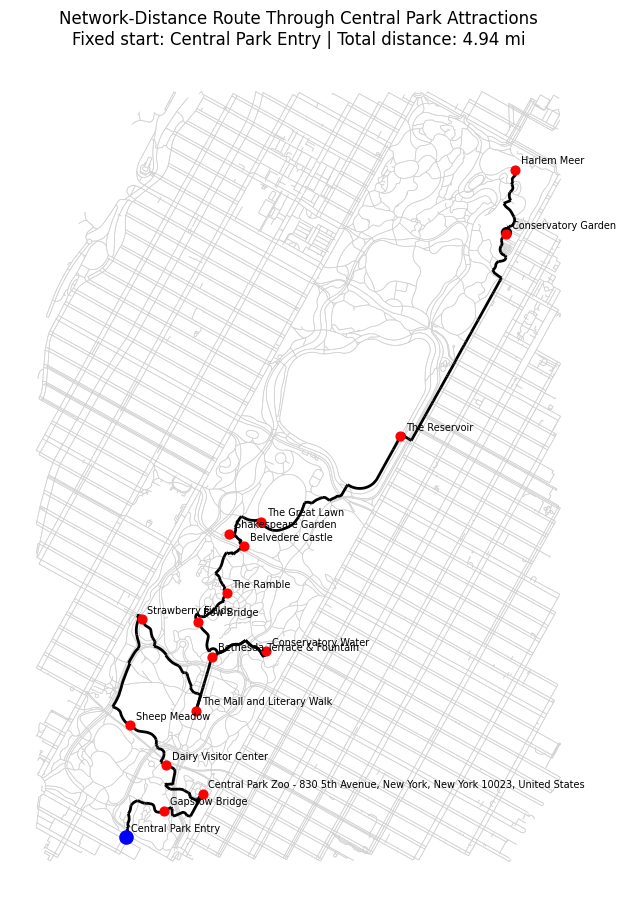

In [109]:
fig, ax = plt.subplots(figsize=(9, 11))

park_edges.plot(ax=ax, color="lightgray", linewidth=0.5, zorder=1)
network_route_gdf.plot(ax=ax, color="black", linewidth=2, zorder=2)
gdf.plot(ax=ax, color="red", markersize=40, zorder=3)
gdf[gdf["label"] == start_label].plot(ax=ax, color="blue", markersize=90, zorder=4)

for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf["label"]):
    ax.annotate(label, xy=(x, y), xytext=(4, 4), textcoords="offset points", fontsize=7)

ax.set_title(
    f"Network-Distance Route Through Central Park Attractions\n"
    f"Fixed start: {start_label} | Total distance: {net_total_distance / 1609.34:.2f} mi"
)

fig.savefig("central_park_network_route.pdf", bbox_inches="tight", pad_inches=0.1)

## Compare: Euclidean vs. network route

Now we can directly compare the Part 1 polyline against the Part 2 route that actually follows Central Park's paths.

In [110]:
euclidean_mi = total_distance / 1609.34
network_mi = net_total_distance / 1609.34
extra_mi = network_mi - euclidean_mi

print(f"Euclidean (straight-line) route: {euclidean_mi:.2f} mi")
print(f"Network (real-path) route:       {network_mi:.2f} mi")
print(
    f"Extra distance from following actual paths: {extra_mi:.2f} mi ({extra_mi / euclidean_mi:+.0%})"
)

Euclidean (straight-line) route: 3.69 mi
Network (real-path) route:       4.94 mi
Extra distance from following actual paths: 1.25 mi (+34%)


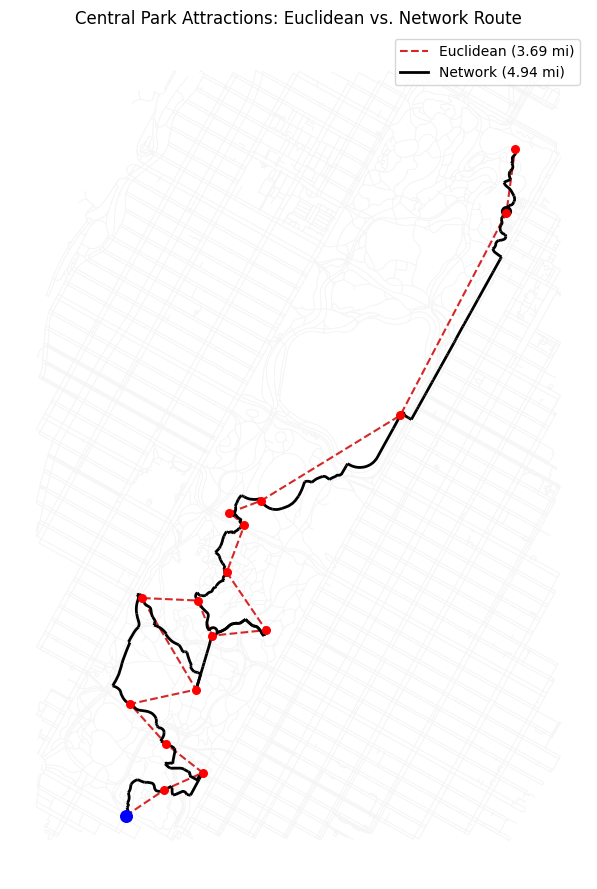

In [111]:
fig, ax = plt.subplots(figsize=(9, 11))

park_edges.plot(ax=ax, color="whitesmoke", linewidth=0.5, zorder=1)
route_gdf.plot(
    ax=ax, color="tab:red", linewidth=1.5, linestyle="--", zorder=2, label="Euclidean"
)
network_route_gdf.plot(ax=ax, color="black", linewidth=2, zorder=3, label="Network")
gdf.plot(ax=ax, color="red", markersize=30, zorder=4)
gdf[gdf["label"] == start_label].plot(ax=ax, color="blue", markersize=70, zorder=5)

ax.legend(
    handles=[
        plt.Line2D(
            [],
            [],
            color="tab:red",
            linestyle="--",
            linewidth=1.5,
            label=f"Euclidean ({euclidean_mi:.2f} mi)",
        ),
        plt.Line2D(
            [], [], color="black", linewidth=2, label=f"Network ({network_mi:.2f} mi)"
        ),
    ]
)
ax.set_title("Central Park Attractions: Euclidean vs. Network Route")

fig.savefig("central_park_route_comparison.pdf", bbox_inches="tight", pad_inches=0.1)